In [1]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import cross_val_score

In [2]:
from google.colab import drive
drive.mount('/content/drive')

data = pd.read_csv('/content/drive/MyDrive/Lab/fitness_dataset.csv')


Mounted at /content/drive


In [3]:
data.head()

,age,height_cm,weight_kg,heart_rate,blood_pressure,sleep_hours,nutrition_quality,activity_index,smokes,gender,is_fit
0,56,152,65,69.6,117.0,NaN,2.37,3.97,no,F,1
1,69,186,95,60.8,114.8,7.5,8.77,3.19,0,F,1
2,46,192,103,61.4,116.4,NaN,8.20,2.03,0,F,0
3,32,189,83,60.2,130.1,7.0,6.18,3.68,0,M,1
4,60,175,99,58.1,115.8,8.0,9.95,4.83,yes,F,1


In [4]:
data.shape

(2000, 11)

In [5]:

datano = data.shape[0] * data.shape[1]
print(datano)

22000


In [6]:
print(data.info())
print(data.isna().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   age                2000 non-null   int64  
 1   height_cm          2000 non-null   int64  
 2   weight_kg          2000 non-null   int64  
 3   heart_rate         2000 non-null   float64
 4   blood_pressure     2000 non-null   float64
 5   sleep_hours        1840 non-null   float64
 6   nutrition_quality  2000 non-null   float64
 7   activity_index     2000 non-null   float64
 8   smokes             2000 non-null   object 
 9   gender             2000 non-null   object 
 10  is_fit             2000 non-null   int64  
dtypes: float64(5), int64(4), object(2)
memory usage: 172.0+ KB
None
age                    0
height_cm              0
weight_kg              0
heart_rate             0
blood_pressure         0
sleep_hours          160
nutrition_quality      0
activity_index         0


In [7]:
# fill sleep_hours missing values with median
median_sleep = data['sleep_hours'].median()
data['sleep_hours'] = data['sleep_hours'].fillna(median_sleep)

print(f"Filled NaN with median: {median_sleep}")
print(f"Missing values left: {data['sleep_hours'].isnull().sum()}")

Filled NaN with median: 7.5
Missing values left: 0


In [8]:

# map the 'smokes' column to 1 for smoker and 0 for non smoker
data['smokes'] = (
    data['smokes']
    .astype(str)
    .str.strip()
    .str.lower()
    .replace({
        'yes': 1, 'y': 1, 'true': '1', 't': '1',
        'no': 0, 'n': 0, 'false': '0', 'f': '0',
        '0': '0', '1': '1'
    })
)

# Convert to numeric (invalid entries become NaN)
data['smokes'] = pd.to_numeric(data['smokes'], errors='coerce')

In [9]:
data['gender'] = (
    data['gender']
    .astype(str)
    .str.strip()
    .str.upper()
    .replace({                  # map all variants to 0 or 1
        'M': 0,                 # Male → 0
        'F': 1,                 # Female → 1
    })
)

print(data['gender'].value_counts())
print(data['gender'].isnull().sum())

gender
1    1030
0     970
Name: count, dtype: int64
0


/tmp/ipykernel_3927/3003638970.py:6: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  .replace({                  # map all variants to 0 or 1


In [10]:
print(data.info())
print(data.isna().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   age                2000 non-null   int64  
 1   height_cm          2000 non-null   int64  
 2   weight_kg          2000 non-null   int64  
 3   heart_rate         2000 non-null   float64
 4   blood_pressure     2000 non-null   float64
 5   sleep_hours        2000 non-null   float64
 6   nutrition_quality  2000 non-null   float64
 7   activity_index     2000 non-null   float64
 8   smokes             2000 non-null   int64  
 9   gender             2000 non-null   int64  
 10  is_fit             2000 non-null   int64  
dtypes: float64(5), int64(6)
memory usage: 172.0 KB
None
age                  0
height_cm            0
weight_kg            0
heart_rate           0
blood_pressure       0
sleep_hours          0
nutrition_quality    0
activity_index       0
smokes               0
gende

In [11]:
data.head()

,age,height_cm,weight_kg,heart_rate,blood_pressure,sleep_hours,nutrition_quality,activity_index,smokes,gender,is_fit
0,56,152,65,69.6,117.0,7.5,2.37,3.97,0,1,1
1,69,186,95,60.8,114.8,7.5,8.77,3.19,0,1,1
2,46,192,103,61.4,116.4,7.5,8.20,2.03,0,1,0
3,32,189,83,60.2,130.1,7.0,6.18,3.68,0,0,1
4,60,175,99,58.1,115.8,8.0,9.95,4.83,1,1,1


#split the dataset to Xtrain features and Ytrain target which is 70% of total dataset and remaining 30% for xtest features and ytest target

In [12]:

# Features: all columns except the target is_fit column
X = data.drop("is_fit", axis=1)

# Target: the column we want to predict
y = data["is_fit"]

# Split: 70% train, 30% test
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

In [13]:
print("X_train shape:", X_train.shape)
print("X_test shape :", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape :", y_test.shape)

X_train shape: (1400, 10)
X_test shape : (600, 10)
y_train shape: (1400,)
y_test shape : (600,)


In [14]:
results = []  # store in dataframe

for depth in range(1, 14):
    # Train a tree with 1 to 14 depth with named 'clf'
    clf = DecisionTreeClassifier(max_depth=depth, random_state=42)
    clf.fit(X_train, y_train)

    # check the accuracy of both train and test dataset
    train_acc = clf.score(X_train, y_train)
    test_acc  = clf.score(X_test, y_test)
    results.append([depth, train_acc, test_acc])

# Convert to DataFrame with proper column names
results = pd.DataFrame(results, columns=["Max Depth", "Train Accuracy", "Test Accuracy"])
results = results.set_index("Max Depth")
results

,Train Accuracy,Test Accuracy
Max Depth,,
1,0.652857,0.600000
2,0.728571,0.703333
3,0.746429,0.718333
4,0.773571,0.726667
5,0.805000,0.736667
6,0.834286,0.726667
7,0.867857,0.721667
8,0.911429,0.701667
9,0.940714,0.688333


#idxmax(): return the index of the maximum value among the test accuracy values

In [15]:
best_depth = results["Test Accuracy"].idxmax() #Return the index of the maximum value.
print(f"Best max_depth = {best_depth}")

Best max_depth = 5


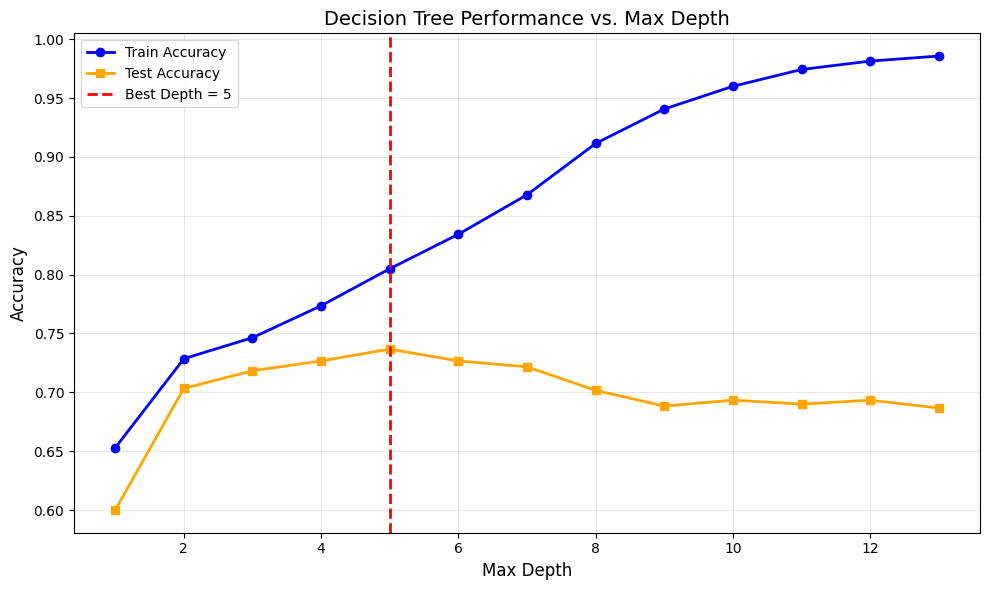

In [16]:
import matplotlib.pyplot as plt
#performance plot to check the optimal depth for training model

plt.figure(figsize=(10, 6))
plt.plot(results.index, results["Train Accuracy"],
         marker='o', linestyle='-', linewidth=2, label="Train Accuracy", color='blue')
plt.plot(results.index, results["Test Accuracy"],
         marker='s', linestyle='-', linewidth=2, label="Test Accuracy", color='orange')

# Mark the best depth
plt.axvline(x=best_depth, color='red', linestyle='--', linewidth=2,
            label=f'Best Depth = {best_depth}')

plt.xlabel("Max Depth", fontsize=12)
plt.ylabel("Accuracy", fontsize=12)
plt.title("Decision Tree Performance vs. Max Depth", fontsize=14)
plt.legend(loc='best')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
#test accuracy increases up to depth 5
#which is best trade off between bias and variance


#best_depth=5, for high test accuracy. it decreases when more than 5 which indicates the overfitting of the model.. as there is high difference between train and test accuracy values

# make the final_tree using Decision tree classification up to best depth Level
0 (Root)\
  Level 1\
    Level 2\
      Level 3\
        Level 4\
            Level 5\  ← Stop here
#Train the model final_tree.fit with X_train → input features and the y_train → target labels

In [17]:
final_tree = DecisionTreeClassifier(max_depth=3, random_state=42)
final_tree.fit(X_train, y_train)


DecisionTreeClassifier(max_depth=3, random_state=42)

In [18]:
y_pred = final_tree.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(accuracy)

0.7183333333333334


The score() method:

Uses the trained tree to predict the labels of X_train and then
compares the predictions with the true labels y_train.
Returns the classification accuracy.

In [19]:
train_acc = final_tree.score(X_train, y_train)
test_acc  = final_tree.score(X_test, y_test)
print(f"\nFinal sklearn model (depth={best_depth}):")
print(f"  Train accuracy: {train_acc:.4f}")
print(f"  Test accuracy : {test_acc:.4f}")


Final sklearn model (depth=5):
  Train accuracy: 0.7464
  Test accuracy : 0.7183


In [20]:
print(final_tree.tree_.node_count)

15


In [21]:
print(final_tree.get_n_leaves())

8


In [22]:
feature_names = data.columns.drop('is_fit').tolist()
importance = pd.Series(final_tree.feature_importances_, index=feature_names)
print("\nTop feature importances:")
print(importance.sort_values(ascending=False))


Top feature importances:
smokes               0.391967
activity_index       0.365365
nutrition_quality    0.165421
age                  0.077247
height_cm            0.000000
weight_kg            0.000000
sleep_hours          0.000000
blood_pressure       0.000000
heart_rate           0.000000
gender               0.000000
dtype: float64


#31.08+25.65+18.99≈75.7%
#Almost classified based on these features which make decisions for model's ability to separate the classes... most effectively based on activity level, smoking status, and nutrition quality

In [23]:
import math
import numpy as np
from collections import Counter

# 1. TreeNode for tree hierarchy and decision nodes

class TreeNode:
    def __init__(self, feature=None, output=None):
        self.feature = feature      # index of feature used for split
        self.output = output        # majority class at this node
        self.children = {}          # {value: child_node}

# 2. Entropy (needed for Gain Ratio)

def entropy(Y):
    total = len(Y)
    if total == 0:
        return 0
    freq = Counter(Y)
    ent = 0.0
    for c in freq:
        p = freq[c] / total
        ent -= p * math.log2(p)
    return ent
# 3. Gain ratio to determine the root node and nodes at different level
def gain_ratio(X, Y, feature):
    """
    Compute Gain Ratio for a given feature.
    """
    total = len(Y)
    values = set(X[:, feature])
    weighted_entropy = 0.0
    split_info = 0.0

    for v in values:
        mask = (X[:, feature] == v)
        Y_sub = Y[mask]
        size = len(Y_sub)
        p = size / total
        weighted_entropy += p * entropy(Y_sub)
        if p > 0:
            split_info -= p * math.log2(p)

    info_gain = entropy(Y) - weighted_entropy

    # Perfect split (only one value) gives infinite gain ratio
    if split_info == 0:
        return float('inf')
    return info_gain / split_info

# 3. Custom tree builder (Gain Ratio only)

def compute_all_gains(X, Y, feature_names):
    """
    Print Gain Ratio for every feature at the root.
    """
    print("\n GAIN RATIO FOR EACH FEATURE (at root)\n")
    for f in range(X.shape[1]):
        gain = gain_ratio(X, Y, f)
        name = feature_names[f] if feature_names else f"X[{f}]"
        print(f"Feature '{name}'  →  gain_ratio: {gain:.6f}")
    print("\n" + "="*50 + "\n")

def build_tree(X, Y, features, classes, feature_names, level=0, max_depth=None):
    """
    Recursively build tree using Gain Ratio.
    """
    total = len(Y)
    freq = Counter(Y)
    curr_entropy = entropy(Y)

    # Stopping conditions
    if len(freq) == 1:
        print(f"Level {level} → Leaf (pure class {Y[0]})")
        return TreeNode(output=Y[0])

    if len(features) == 0 or (max_depth is not None and level >= max_depth):
        majority = max(freq, key=freq.get)
        print(f"Level {level} → Leaf (majority class {majority})")
        return TreeNode(output=majority)

    # Find best feature by Gain Ratio
    best_gain = -math.inf
    best_feature = None
    best_splits = None

    for f in features:
        current_gain = gain_ratio(X, Y, f)
        if current_gain > best_gain:
            best_gain = current_gain
            best_feature = f
            # Store splits for recursion
            best_splits = {}
            for v in set(X[:, f]):
                mask = (X[:, f] == v)
                best_splits[v] = (X[mask], Y[mask])

    # Print split details for proper implementation of node conditions
    feat_name = feature_names[best_feature] if feature_names else f"X[{best_feature}]"
    print(f"\nLevel {level} → Split on '{feat_name}' (index {best_feature})")
    print(f"  Entropy before = {curr_entropy:.4f}")
    print(f"  Best gain_ratio = {best_gain:.6f}")
    print(f"  Number of samples = {total}")
    for c in classes:
        print(f"    class {c}: {freq.get(c, 0)}")

    # Create node and recurse
    node = TreeNode(feature=best_feature, output=max(freq, key=freq.get))
    remaining_features = [f for f in features if f != best_feature]

    for val, (X_sub, Y_sub) in best_splits.items():
        print(f"    → value {val}: {len(Y_sub)} samples")
        child = build_tree(X_sub, Y_sub, remaining_features, classes,
                           feature_names, level + 1, max_depth)
        node.children[val] = child

    return node

def tree(X, Y, feature_names, max_depth=None):
    """
    Wrapper to build the full Gain‑Ratio tree.
    """
    features = list(range(X.shape[1]))
    classes = set(Y)
    print("\n" + "="*60)
    print("BUILDING CUSTOM DECISION TREE (Gain Ratio)")
    print(f"Total samples: {len(Y)}")
    print("="*60)

    compute_all_gains(X, Y, feature_names)
    root = build_tree(X, Y, features, classes, feature_names, 0, max_depth)
    return root

# 4. Tree hierarchy printer

def print_tree_hierarchy(node, feature_names, depth=0, prefix=""):
    """
    Pretty‑print the tree with column names and depth.
    """
    if not node.children:
        print(f"{prefix}Leaf → {node.output}")
        return

    feature_name = feature_names[node.feature] if feature_names else f"X[{node.feature}]"
    print(f"{prefix}Depth {depth}: Split on '{feature_name}'")

    for val, child in node.children.items():
        new_prefix = prefix + "  "
        print(f"{new_prefix}when {feature_name} = {val}:")
        print_tree_hierarchy(child, feature_names, depth + 1, new_prefix + "  ")
print(tree)

<function tree at 0x7f00199ed6c0>


### Overall Importance Ranking

1. **`build_tree()`** – Constructs the complete decision tree recursively.
2. **`gain_ratio()`** – Selects the optimal splitting feature at every node.
3. **`tree()`** – Initializes and manages the training process.
4. **`entropy()`** – Computes entropy for Gain Ratio calculation.
5. **`compute_all_gains()`** – Displays Gain Ratio values for feature analysis.
6. **`TreeNode`** – Represents the internal structure of the decision tree.
7. **`print_tree_hierarchy()`** – Visualizes the constructed decision tree.

In [24]:
# Convert to NumPy arrays (if not already)
if not isinstance(X_train, np.ndarray):
    X_train = np.array(X_train)
if not isinstance(y_train, np.ndarray):
    y_train = np.array(y_train)

# Convert feature_names to a plain list
if not isinstance(feature_names, list):
    feature_names = list(feature_names)

# Now build the custom tree (metric removed and based on default is gain_ratio)
custom_root = tree(X_train, y_train, feature_names, max_depth=2)

print("\n=== CUSTOM TREE HIERARCHY ===")
print_tree_hierarchy(custom_root, feature_names)


BUILDING CUSTOM DECISION TREE (Gain Ratio)
Total samples: 1400

 GAIN RATIO FOR EACH FEATURE (at root)

Feature 'age'  →  gain_ratio: 0.011200
Feature 'height_cm'  →  gain_ratio: 0.004305
Feature 'weight_kg'  →  gain_ratio: 0.007383
Feature 'heart_rate'  →  gain_ratio: 0.033371
Feature 'blood_pressure'  →  gain_ratio: 0.038087
Feature 'sleep_hours'  →  gain_ratio: 0.009257
Feature 'nutrition_quality'  →  gain_ratio: 0.061968
Feature 'activity_index'  →  gain_ratio: 0.038784
Feature 'smokes'  →  gain_ratio: 0.081819
Feature 'gender'  →  gain_ratio: 0.009703



Level 0 → Split on 'smokes' (index 8)
  Entropy before = 0.9705
  Best gain_ratio = 0.081819
  Number of samples = 1400
    class 0: 841
    class 1: 559
    → value 0.0: 759 samples

Level 1 → Split on 'nutrition_quality' (index 6)
  Entropy before = 0.9933
  Best gain_ratio = 0.082621
  Number of samples = 759
    class 0: 343
    class 1: 416
    → value 0.54: 1 samples
Level 2 → Leaf (pure class 0)
    → value 1.75: 3 samples

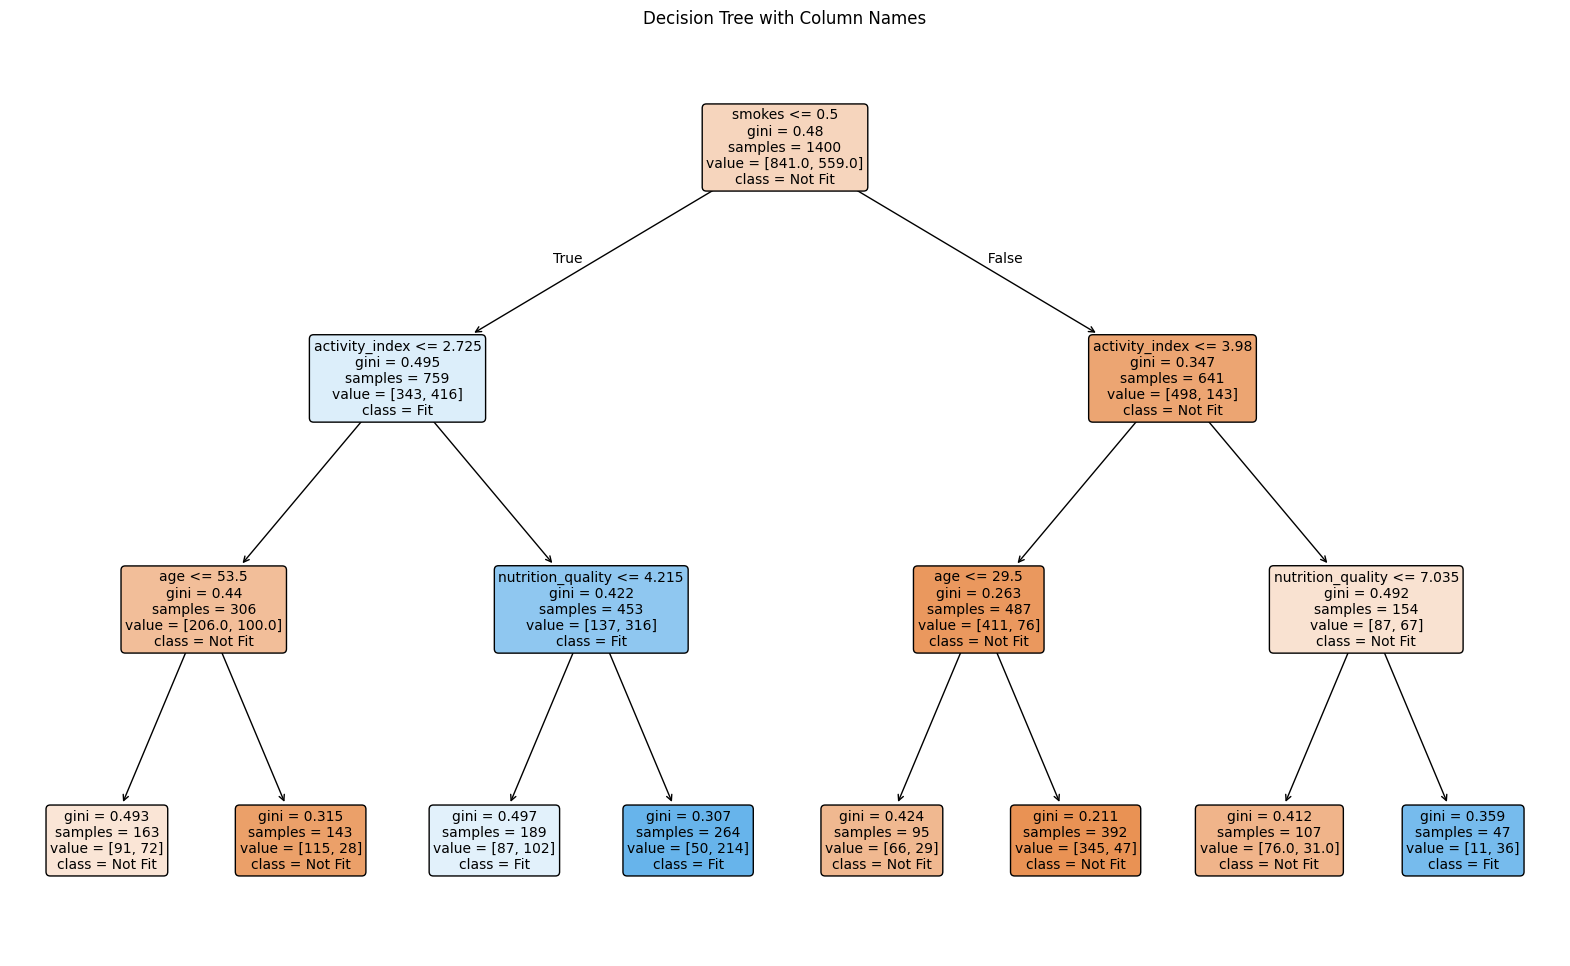

In [25]:
from sklearn import tree
plt.figure(figsize=(20, 12))
tree.plot_tree(final_tree,
               feature_names=feature_names,
               class_names=['Not Fit', 'Fit'],
               filled=True,
               rounded=True,
               fontsize=10)
plt.title("Decision Tree with Column Names")
plt.show()

In [26]:
# Step 1: Create your own input (using the first sample row as an example)
my_data = pd.DataFrame({
    'age':              [20],   # Range: 20–70 (years)
    'height_cm':        [152],  # Range: 150–190 (cm)
    'weight_kg':        [65],   # Range: 50–100 (kg)
    'heart_rate':       [69.6], # Range: 60–100 (bpm)
    'blood_pressure':   [117.0],# Range: 110–150 (mmHg)
    'sleep_hours':      [7.5],  # Range: 5–9 (hours)
    'nutrition_quality':[15], # Range: 1–10 (higher is better)
    'activity_index':   [3.97], # Range: typically 0–5, but can be higher
    'smokes':           [0],    # 0 = non‑smoker, 1 = smoker
    'gender':           [1]     # 0 = male, 1 = female (as per your encoding)
})

# Step 2: Ensure column order matches training data (X)
# Since all features are numeric, no encoding is needed – just reindex.
my_data = my_data.reindex(columns=X.columns, fill_value=0)

# Step 3: Predict (using your trained model, e.g., final_tree)
prediction = final_tree.predict(my_data)
print(f"Predicted fitness (is_fit): {prediction[0]}")   # 1 = fit, 0 = not fit

Predicted fitness (is_fit): 1
